In [1]:
import os
import sys

# add the source directory to system path, so that relative imports work
# this fix is only for Jupyter Notebooks
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from orbital_mechanics.solar_system import SolarSystem
from common.constants import ALTAIRA_MU as MU, ALTAIRA_AU as AU, YEAR

# Loading and preprocessing data

In [3]:
ss = SolarSystem()

# planets
planets_df = ss.bodies_df.iloc[ss.planets_idx].copy()
planets_df

,id,name,mu,R,A,e,i,RAAN,AOP,MA,Wgt,type
0,1,Vulcan,6.589064e+08,133020.7,1.381198e+07,0.000,0.000000,0.000000,5.504280,5.630153,0.1,planet
1,2,Yavin,6.363037e+06,18013.2,1.285282e+08,0.050,0.052360,1.928571,2.585443,2.710671,1.0,planet
2,3,Eden,4.438536e+05,6697.4,1.795174e+08,0.007,0.017453,1.875740,6.217002,0.905774,2.0,planet
3,4,Hoth,2.844417e+05,5498.8,4.396270e+08,0.050,0.209440,1.666737,0.330269,2.124415,3.0,planet
4,1000,Yandi,0.000000e+00,0.0,5.963254e+08,0.077,0.184848,1.401517,1.288210,2.698401,5.0,planet
5,5,Beyonc,4.932276e+07,63476.2,1.119106e+09,0.070,0.000000,3.845292,2.039644,1.131322,7.0,planet
6,6,Bespin,1.203771e+08,63661.4,2.138564e+09,0.119,0.006981,3.028600,5.817566,5.427485,10.0,planet
7,7,Jotunn,6.341816e+06,23865.3,2.622319e+09,0.150,0.087266,3.650705,0.285658,3.475108,15.0,planet
8,8,Wakonyingo,6.598433e+06,13531.4,5.115499e+09,0.095,0.261799,0.588577,1.875566,2.760291,20.0,planet
9,9,Rogue1,6.634665e+07,109471.2,1.004897e+10,0.100,3.054326,2.822075,5.550147,4.894968,35.0,planet


In [4]:
# calculate time period, velocity, angular momentum, and orbit plane vectors
mean_motion = np.sqrt(MU/planets_df['A']**3)
planets_df['period'] = 2*np.pi/mean_motion

half_sma_mean_motion = np.sqrt(8*MU/planets_df['A']**3)
planets_df['half_sma_period'] = 2*np.pi/half_sma_mean_motion

v = planets_df['A']*mean_motion
p = planets_df['A']*(1-planets_df['e']**2)
h = np.sqrt(MU * p)

planets_df['v'] = v
planets_df['h'] = h

hx = np.sin(planets_df['RAAN'])*np.sin(planets_df['i'])
hy = -np.cos(planets_df['RAAN'])*np.sin(planets_df['i'])
hz = np.cos(planets_df['i'])

planets_df['hx'] = hx
planets_df['hy'] = hy
planets_df['hz'] = hz

planets_df

,id,name,mu,R,A,e,i,RAAN,AOP,MA,Wgt,type,period,half_sma_period,v,h,hx,hy,hz
0,1,Vulcan,6.589064e+08,133020.7,1.381198e+07,0.000,0.000000,0.000000,5.504280,5.630153,0.1,planet,8.639994e+05,3.054699e+05,100.443642,1.387326e+09,0.000000,-0.000000,1.000000
1,2,Yavin,6.363037e+06,18013.2,1.285282e+08,0.050,0.052360,1.928571,2.585443,2.710671,1.0,planet,2.452603e+07,8.671260e+06,32.926927,4.226746e+09,0.049022,0.018328,0.998630
2,3,Eden,4.438536e+05,6697.4,1.795174e+08,0.007,0.017453,1.875740,6.217002,0.905774,2.0,planet,4.048456e+07,1.431345e+07,27.861028,5.001418e+09,0.016647,0.005240,0.999848
3,4,Hoth,2.844417e+05,5498.8,4.396270e+08,0.050,0.209440,1.666737,0.330269,2.124415,3.0,planet,1.551515e+08,5.485433e+07,17.803619,7.817162e+09,0.206956,0.019917,0.978148
4,1000,Yandi,0.000000e+00,0.0,5.963254e+08,0.077,0.184848,1.401517,1.288210,2.698401,5.0,planet,2.451062e+08,8.665814e+07,15.286526,9.088680e+09,0.181170,-0.030965,0.982964
5,5,Beyonc,4.932276e+07,63476.2,1.119106e+09,0.070,0.000000,3.845292,2.039644,1.131322,7.0,planet,6.301386e+08,2.227876e+08,11.158733,1.245717e+10,-0.000000,0.000000,1.000000
6,6,Bespin,1.203771e+08,63661.4,2.138564e+09,0.119,0.006981,3.028600,5.817566,5.427485,10.0,planet,1.664611e+09,5.885290e+08,8.072152,1.714015e+10,0.000787,0.006937,0.999976
7,7,Jotunn,6.341816e+06,23865.3,2.622319e+09,0.150,0.087266,3.650705,0.285658,3.475108,15.0,planet,2.260256e+09,7.991212e+08,7.289667,1.889956e+10,-0.042480,0.076102,0.996195
8,8,Wakonyingo,6.598433e+06,13531.4,5.115499e+09,0.095,0.261799,0.588577,1.875566,2.760291,20.0,planet,6.158308e+09,2.177291e+09,5.219230,2.657822e+10,0.143691,-0.215268,0.965926
9,9,Rogue1,6.634665e+07,109471.2,1.004897e+10,0.100,3.054326,2.822075,5.550147,4.894968,35.0,planet,1.695555e+10,5.994693e+09,3.723828,3.723308e+10,0.027376,0.082745,-0.996195


In [5]:
# convert the values to human readable units
planets_df[['i','RAAN','AOP','MA']] = np.rad2deg(planets_df[['i','RAAN','AOP','MA']])

planets_df['A'] /= AU
planets_df['period'] /= YEAR
planets_df['half_sma_period'] /= YEAR

In [6]:
planets_df

,id,name,mu,R,A,e,i,RAAN,AOP,MA,Wgt,type,period,half_sma_period,v,h,hx,hy,hz
0,1,Vulcan,6.589064e+08,133020.7,0.092327,0.000,0.000,0.000,315.372,322.584,0.1,planet,0.027378,0.009680,100.443642,1.387326e+09,0.000000,-0.000000,1.000000
1,2,Yavin,6.363037e+06,18013.2,0.859158,0.050,3.000,110.499,148.135,155.310,1.0,planet,0.777183,0.274776,32.926927,4.226746e+09,0.049022,0.018328,0.998630
2,3,Eden,4.438536e+05,6697.4,1.200000,0.007,1.000,107.472,356.208,51.897,2.0,planet,1.282878,0.453566,27.861028,5.001418e+09,0.016647,0.005240,0.999848
3,4,Hoth,2.844417e+05,5498.8,2.938725,0.050,12.000,95.497,18.923,121.720,3.0,planet,4.916454,1.738229,17.803619,7.817162e+09,0.206956,0.019917,0.978148
4,1000,Yandi,0.000000e+00,0.0,3.986189,0.077,10.591,80.301,73.809,154.607,5.0,planet,7.766948,2.746031,15.286526,9.088680e+09,0.181170,-0.030965,0.982964
5,5,Beyonc,4.932276e+07,63476.2,7.480760,0.070,0.000,220.319,116.863,64.820,7.0,planet,19.967888,7.059715,11.158733,1.245717e+10,-0.000000,0.000000,1.000000
6,6,Bespin,1.203771e+08,63661.4,14.295419,0.119,0.400,173.526,333.322,310.972,10.0,planet,52.748348,18.649357,8.072152,1.714015e+10,0.000787,0.006937,0.999976
7,7,Jotunn,6.341816e+06,23865.3,17.529119,0.150,5.000,209.170,16.367,199.109,15.0,planet,71.623195,25.322623,7.289667,1.889956e+10,-0.042480,0.076102,0.996195
8,8,Wakonyingo,6.598433e+06,13531.4,34.195000,0.095,15.000,33.723,107.462,158.153,20.0,planet,195.145016,68.994182,5.219230,2.657822e+10,0.143691,-0.215268,0.965926
9,9,Rogue1,6.634665e+07,109471.2,67.173237,0.100,175.000,161.693,318.000,280.461,35.0,planet,537.289026,189.960357,3.723828,3.723308e+10,0.027376,0.082745,-0.996195


# Plots of various key parameters

In [7]:
# further analysis will only consider planets whose half_sma_period < 30 years
# i.e. till Jotunn. This is because it is not possible (or very difficult) to
# visit the other planets more than once in reasonable time

feasible_planets = planets_df[planets_df['half_sma_period'] < 30].copy()

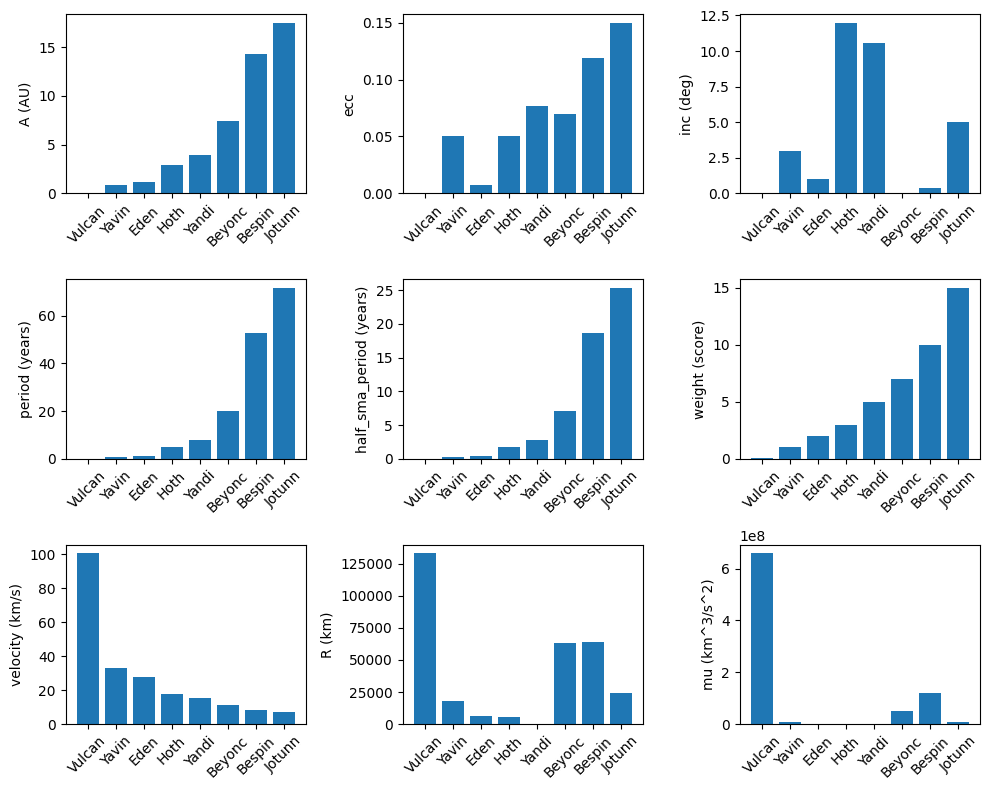

In [8]:
# plot the orbital data of the various feasible planets

fields_to_plot = ['A', 'e', 'i', 'period', 'half_sma_period', 'Wgt', 'v', 'R', 'mu']
field_labels = ['A (AU)', 'ecc', 'inc (deg)', 'period (years)', 'half_sma_period (years)', 'weight (score)', 'velocity (km/s)', 'R (km)', 'mu (km^3/s^2)']

fig, axes = plt.subplots(3, 3, figsize=(10,8))

for i in range(len(fields_to_plot)):
    ax = axes[i//3, i%3]
    f = fields_to_plot[i]
    ax.bar(feasible_planets['name'], feasible_planets[f])
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel(field_labels[i])

fig.tight_layout()
plt.show()
    

# Gravity assist analysis

In [9]:
import pandas as pd
import common.gravity_assist as ga

test_vels = np.sort(np.array([5, 10, 25, 50, 75, 100, 150, 200]))

ga_df = pd.DataFrame(columns=['planet', 'mu', 'R', 'v', *[f'{v}_min' for v in test_vels], *[f'{v}_max' for v in test_vels]])
ga_df[['planet','mu','R','v']] = feasible_planets[['name','mu','R','v']]
ga_df = ga_df.reset_index(drop=True)

In [10]:
for i in range(len(ga_df)):
    row = ga_df.loc[i]
    for j in range(len(test_vels)):
        v_inf = 0.01*test_vels[j]*row['v']
        ta_min, ta_max = ga.minmax_turn_angle(row['mu'], row['R'],
                                               v_inf, 0.1*row['R'], 100*row['R'])
        ta_min = np.rad2deg(ta_min)
        ta_max = np.rad2deg(ta_max)

        ga_df.loc[i, f'{test_vels[j]}_min'] = ta_min
        ga_df.loc[i, f'{test_vels[j]}_max'] = ta_max

ga_df

,planet,mu,R,v,5_min,10_min,25_min,50_min,75_min,100_min,150_min,200_min,5_max,10_max,25_max,50_max,75_max,100_max,150_max,200_max
0,Vulcan,6.589064e+08,133020.7,100.443642,82.657527,38.186206,8.276736,2.185816,0.981831,0.554353,0.247042,0.139092,167.899785,155.966385,122.606136,79.729952,52.517997,35.949781,19.056729,11.522557
1,Yavin,6.363037e+06,18013.2,32.926927,68.580687,28.234539,5.626528,1.459843,0.65343,0.368472,0.164058,0.092341,165.163665,150.633154,111.330736,65.679122,40.355854,26.418903,13.360533,7.906636
2,Eden,4.438536e+05,6697.4,27.861028,29.273013,8.940649,1.529216,0.386158,0.171948,0.096784,0.043035,0.024211,151.297735,124.716188,67.27524,27.40842,13.928713,8.260601,3.821805,2.181319
3,Hoth,2.844417e+05,5498.8,17.803619,46.230829,15.991955,2.888158,0.735877,0.328226,0.184858,0.082233,0.046271,159.109323,139.059087,89.432207,43.730695,24.092907,14.845893,7.093029,4.099066
4,Yandi,0.000000e+00,0.0,15.286526,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Beyonc,4.932276e+07,63476.2,11.158733,147.937357,118.789583,59.619924,22.85949,11.359686,6.671855,3.062966,1.743162,176.598653,173.201049,163.067676,146.58775,130.952953,116.45439,91.453252,71.815014
6,Bespin,1.203771e+08,63661.4,8.072152,164.937912,150.195663,110.437781,64.65107,39.521842,25.793301,13.004015,7.685285,178.42249,176.845353,172.119911,164.286185,156.543792,148.935014,134.267577,120.532643
7,Jotunn,6.341816e+06,23865.3,7.289667,144.326872,112.602556,52.466155,19.03034,9.280632,5.407997,2.467519,1.401105,176.200567,172.406349,161.106373,142.838053,125.719226,110.108148,83.968699,64.274613


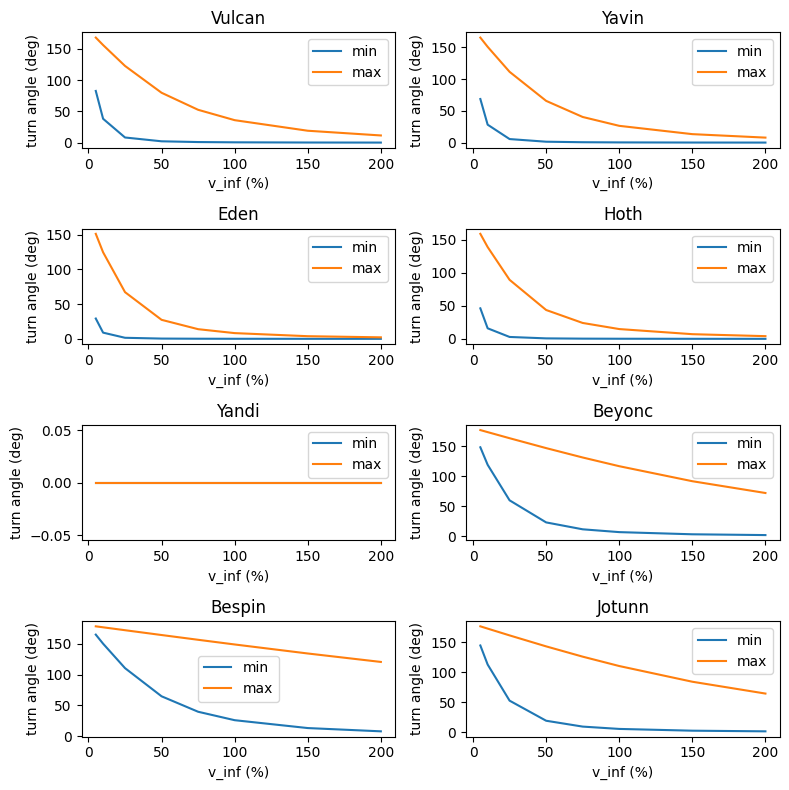

In [11]:
# now plot the turn angles for each planet
fig, axes = plt.subplots(4, 2, figsize=(8,8))

for i in range(len(ga_df)):
    row = ga_df.loc[i]
    ax = axes[i//2, i%2]

    min_arr = row[[f'{v}_min' for v in test_vels]]
    max_arr = row[[f'{v}_max' for v in test_vels]]

    ax.plot(test_vels, min_arr, test_vels, max_arr)
    ax.legend(['min', 'max'])
    ax.set_xlabel('v_inf (%)')
    ax.set_ylabel('turn angle (deg)')
    ax.set_title(row['planet'])

fig.tight_layout()
plt.show()

In [12]:
# get an average idea of turn angles *hand-wavy
lower_vels = test_vels[:len(test_vels)//2]
higher_vels = test_vels[len(test_vels)//2:]

ll_median = np.median(ga_df[[f'{v}_min' for v in lower_vels]], axis=1)
lu_median = np.median(ga_df[[f'{v}_max' for v in lower_vels]], axis=1)
ga_df.insert(4, 'lower_v_ta', (ll_median + lu_median)/2)

ul_median = np.median(ga_df[[f'{v}_min' for v in higher_vels]], axis=1)
uu_median = np.median(ga_df[[f'{v}_max' for v in higher_vels]], axis=1)
ga_df.insert(5, 'higher_v_ta', (ul_median + uu_median)/2)

ga_df

,planet,mu,R,v,lower_v_ta,higher_v_ta,5_min,10_min,25_min,50_min,...,150_min,200_min,5_max,10_max,25_max,50_max,75_max,100_max,150_max,200_max
0,Vulcan,6.589064e+08,133020.7,100.443642,81.258866,13.951976,82.657527,38.186206,8.276736,2.185816,...,0.247042,0.139092,167.899785,155.966385,122.606136,79.729952,52.517997,35.949781,19.056729,11.522557
1,Yavin,6.363037e+06,18013.2,32.926927,73.956239,10.077992,68.580687,28.234539,5.626528,1.459843,...,0.164058,0.092341,165.163665,150.633154,111.330736,65.679122,40.355854,26.418903,13.360533,7.906636
2,Eden,4.438536e+05,6697.4,27.861028,50.615323,3.055556,29.273013,8.940649,1.529216,0.386158,...,0.043035,0.024211,151.297735,124.716188,67.27524,27.40842,13.928713,8.260601,3.821805,2.181319
3,Hoth,2.844417e+05,5498.8,17.803619,61.842852,5.551504,46.230829,15.991955,2.888158,0.735877,...,0.082233,0.046271,159.109323,139.059087,89.432207,43.730695,24.092907,14.845893,7.093029,4.099066
4,Yandi,0.000000e+00,0.0,15.286526,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Beyonc,4.932276e+07,63476.2,11.158733,128.669558,54.410616,147.937357,118.789583,59.619924,22.85949,...,3.062966,1.743162,176.598653,173.201049,163.067676,146.58775,130.952953,116.45439,91.453252,71.815014
6,Bespin,1.203771e+08,63661.4,8.072152,152.399677,80.499977,164.937912,150.195663,110.437781,64.65107,...,13.004015,7.685285,178.42249,176.845353,172.119911,164.286185,156.543792,148.935014,134.267577,120.532643
7,Jotunn,6.341816e+06,23865.3,7.289667,124.645358,50.488091,144.326872,112.602556,52.466155,19.03034,...,2.467519,1.401105,176.200567,172.406349,161.106373,142.838053,125.719226,110.108148,83.968699,64.274613


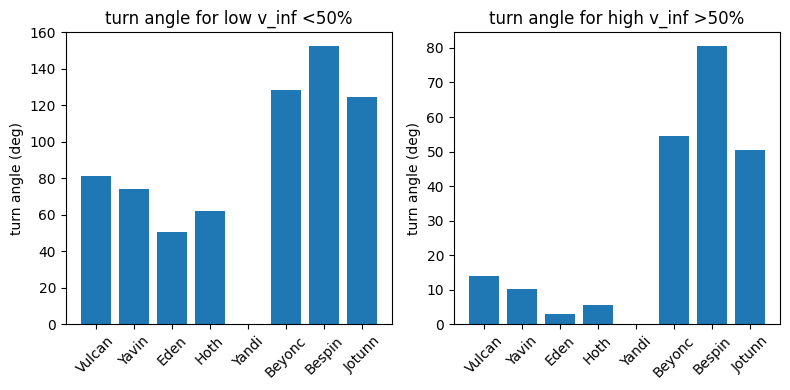

In [13]:
# plot the above averages
fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].bar(ga_df['planet'], ga_df['lower_v_ta'])
axes[0].set_ylabel('turn angle (deg)')
axes[0].set_title('turn angle for low v_inf <50%')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(ga_df['planet'], ga_df['higher_v_ta'])
axes[1].set_ylabel('turn angle (deg)')
axes[1].set_title('turn angle for high v_inf >50%')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

# Analysis of post-first braking burn

In [14]:
# assuming jotunn, bespin or beyonc as the higher point of the orbit
# and 0.01*AU as the lower point of the orbit, we derive the semi-major axis,
# eccentricity, energy, velocity at periapsis, time period

ap_bodies = planets_df[planets_df['name'].isin(['Jotunn', 'Bespin', 'Beyonc'])].copy()
ap_bodies = ap_bodies.reset_index(drop=True)
ap_bodies

,id,name,mu,R,A,e,i,RAAN,AOP,MA,Wgt,type,period,half_sma_period,v,h,hx,hy,hz
0,5,Beyonc,4.932276e+07,63476.2,7.480760,0.070,0.0,220.319,116.863,64.820,7.0,planet,19.967888,7.059715,11.158733,1.245717e+10,-0.000000,0.000000,1.000000
1,6,Bespin,1.203771e+08,63661.4,14.295419,0.119,0.4,173.526,333.322,310.972,10.0,planet,52.748348,18.649357,8.072152,1.714015e+10,0.000787,0.006937,0.999976
2,7,Jotunn,6.341816e+06,23865.3,17.529119,0.150,5.0,209.170,16.367,199.109,15.0,planet,71.623195,25.322623,7.289667,1.889956e+10,-0.042480,0.076102,0.996195


In [26]:
out_df = pd.DataFrame(columns=['planet','rp (AU)','ra (AU)','a (AU)','e','energy (km^2/s^2)','v_periapsis (km/s)','deltav (km/s)','period (years)'])
out_df['planet'] = ap_bodies['name']

for i in range(len(ap_bodies)):
    rp = 0.01*AU
    ra = ap_bodies.loc[i]['A'] * AU
    a = (ra+rp)/2
    e = (ra-rp)/2/a
    energy = -MU/2/a
    v = np.sqrt(2*(energy + MU/rp))
    dv = np.sqrt(2*MU/rp) - v     # delta v assuming transition from parabolic flight
    T = 2*np.pi*np.sqrt(a**3/MU)

    out_df.loc[i,'rp (AU)'] = rp / AU
    out_df.loc[i,'ra (AU)'] = ra / AU
    out_df.loc[i,'a (AU)'] = a / AU
    out_df.loc[i,'e'] = e
    out_df.loc[i,'energy (km^2/s^2)'] = energy
    out_df.loc[i,'v_periapsis (km/s)'] = v
    out_df.loc[i, 'deltav (km/s)'] = dv
    out_df.loc[i,'period (years)'] = T / YEAR

out_df

,planet,rp (AU),ra (AU),a (AU),e,energy (km^2/s^2),v_periapsis (km/s),deltav (km/s),period (years)
0,Beyonc,0.01,7.48076,3.74538,0.99733,-124.351102,431.332992,0.288199,7.073875
1,Bespin,0.01,14.295419,7.152709,0.998602,-65.114087,431.470305,0.150886,18.668929
2,Jotunn,0.01,17.529119,8.76956,0.99886,-53.108954,431.498128,0.123063,25.344295


In [27]:
# assuming various test energies, we calculate the delta v required at periapsis:
# more information on these test energies can be found in the initial_cond_db.ipynb file

test_energies = np.array([400, 300, 200, 100, 50, 20, 10, 0])

for i in range(len(test_energies)):
    dv = np.sqrt(2*(test_energies[i] + MU/2.8/AU)) - 23.5875
    dE = test_energies[i] + 54.4873
    print(f"energy:{test_energies[i]} km^2/s^2,  dv={dv} km/s   dE={dE} km^2/s^2")

energy:400 km^2/s^2,  dv=14.692336739314811 km/s   dE=454.4873 km^2/s^2
energy:300 km^2/s^2,  dv=11.9842008419417 km/s   dE=354.4873 km^2/s^2
energy:200 km^2/s^2,  dv=9.052136958590637 km/s   dE=254.4873 km^2/s^2
energy:100 km^2/s^2,  dv=5.829262241766102 km/s   dE=154.4873 km^2/s^2
energy:50 km^2/s^2,  dv=4.077385699901164 km/s   dE=104.4873 km^2/s^2
energy:20 km^2/s^2,  dv=2.9708489846149106 km/s   dE=74.4873 km^2/s^2
energy:10 km^2/s^2,  dv=2.5916119174924646 km/s   dE=64.4873 km^2/s^2
energy:0 km^2/s^2,  dv=2.2067997731784885 km/s   dE=54.4873 km^2/s^2


In conclusion from both this notebook, the initial cond notebook and the scoring chart, we can choose an initial velocity of around 12-15 km/s and a time of flight between 15-25 years for x0 to planetX intercept